<a href="https://colab.research.google.com/github/gph05010/Daily-Study-Log-DeepLearning/blob/main/DeepLearning/ex04_1_%EC%9D%B4%EB%AF%B8%EC%A7%80%EB%8D%B0%EC%9D%B4%ED%84%B0%EC%A0%84%EC%B2%98%EB%A6%AC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 목표
- 개, 고양이 사진들을 학습시키기 위한 전처리
  - array형으로 변환
  - 이미지 크기 조절

In [1]:
from zipfile import ZipFile

In [ ]:
# 구글 드라이브 마운트
# 코랩 임시저장소 대신 파일 영구저장을 위한 google drive 마운트(연동)
from google.colab import drive
drive.mount('/content/drive')

In [2]:
%cd /content/drive/MyDrive/00 딥러닝

/content/drive/MyDrive/00 딥러닝


In [3]:
# # 1. 압축 파일 해제
# zip_file_path = "./data/cats_and_dogs_filtered.zip"

# with ZipFile(zip_file_path, "r") as f : # 파일 열고 닫기 알아서 해주는 keyword
#   f.extractall(path="./data/")

In [4]:
# 폴더 경로 지정
train_cats_dir = "./data/cats_and_dogs_filtered/train/cats"
train_dogs_dir = "./data/cats_and_dogs_filtered/train/dogs"
test_cats_dir = "./data/cats_and_dogs_filtered/test/cats"
test_dogs_dir = "./data/cats_and_dogs_filtered/test/dogs"

In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import PIL.Image as pimg

In [6]:
train_cats_fn = os.listdir(train_cats_dir) # 각각 폴더 안에 있는 파일 이름들을 가져오기
train_dogs_fn = os.listdir(train_dogs_dir)
test_cats_fn = os.listdir(test_cats_dir)
test_dogs_fn = os.listdir(test_dogs_dir)
# 해당 폴더 안에 있는 파일 이름이 list에 담겨 있음

In [9]:
len(train_cats_fn), len(train_dogs_fn), len(test_cats_fn), len(test_dogs_fn)

(1000, 1000, 500, 500)

array([[[164, 145, 114],
        [170, 154, 120],
        [166, 151, 117],
        ...,
        [ 41,  35,  37],
        [ 39,  35,  36],
        [ 35,  33,  34]],

       [[167, 149, 121],
        [171, 155, 121],
        [169, 154, 120],
        ...,
        [ 41,  35,  37],
        [ 40,  35,  37],
        [ 37,  35,  36]],

       [[163, 145, 121],
        [170, 154, 122],
        [173, 159, 125],
        ...,
        [ 41,  35,  37],
        [ 40,  36,  37],
        [ 38,  36,  37]],

       ...,

       [[133, 149, 167],
        [158, 172, 189],
        [148, 159, 176],
        ...,
        [ 11,  15,  80],
        [ 10,  14,  75],
        [  9,  14,  70]],

       [[152, 168, 182],
        [138, 150, 166],
        [149, 160, 175],
        ...,
        [ 17,  21,  85],
        [ 12,  16,  77],
        [  9,  14,  70]],

       [[127, 141, 154],
        [144, 156, 170],
        [138, 150, 164],
        ...,
        [ 16,  20,  84],
        [ 10,  14,  76],
        [  9,  14,  70]]], dtype=uint8)
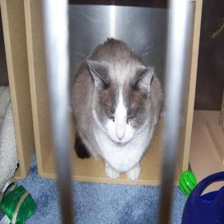

In [12]:
train_cats_fn[150] # 이미지 파일의 이름
# 이미지 전체의 경로가 있어야 해당 파일에 접근 가능
temp_path = os.path.join(train_cats_dir, train_cats_fn[150])

temp_img = pimg.open(temp_path).resize((224, 224))
np.array(temp_img)

In [13]:
# train_cats_dir 폴더에 있는 사진 크기 조정 + array 변환
imgs = []

from tqdm import tqdm # 반복문 진행 현황 시각화
for fn in tqdm(train_cats_fn) :
  # 1. 이미지 파일 하나의 경로를 설정
  temp_path = os.path.join(train_cats_dir, fn)

  # 2. 이미지 불러오기 + 리사이징(CNN 모델이 요구한 크기로 변경)
  temp_img = pimg.open(temp_path).resize((224, 224))

  # 3. array 생성 후 imgs 저장
  imgs.append(np.array(temp_img))

100%|██████████| 1000/1000 [00:07<00:00, 128.97it/s]


In [14]:
temp = np.array(imgs)

In [15]:
# 함수로 만들어서 각 폴더들에 적용해보기
# prepro_imgs(dir_path, file_names, img_size = (224, 224))

# 1. 작업이 끝난 이미지를 담아줄 리스트 생성

# 2. for문 활용해서 file_names에 있는 각각 파일들에 접근
# 2-1. 이미지 전체 경로 설정
# 2-2. 이미지 불러오기 및 리사이징
# 2-3. 배열로 형변환해서 1번 리스트에 저장

# 3. 1번 리스트 배열로 변환해서 반환

def prepro_imgs(dir_path, file_names, img_size = (224, 224)) :
  imgs = []

  for fn in tqdm(file_names) :
    temp_path = os.path.join(dir_path, fn)
    temp_img = pimg.open(temp_path).resize(img_size)
    imgs.append(np.array(temp_img))

  return np.array(imgs)

In [17]:
X_train_cats = prepro_imgs(train_cats_dir, train_cats_fn)
X_train_dogs = prepro_imgs(train_dogs_dir, train_dogs_fn)
X_test_cats = prepro_imgs(test_cats_dir, test_cats_fn)
X_test_dogs = prepro_imgs(test_dogs_dir, test_dogs_fn)

100%|██████████| 500/500 [00:04<00:00, 124.47it/s]


In [18]:
X_test_dogs.shape이
# 마지막 3의 의미 : 컬러 사진이다! -> 컬러 사진을 표현하기 위해서는 RGB 3개의 밴드가 필요

(500, 224, 224, 3)

In [19]:
# 병합 -> cat, dog으로 나눠져 있던 train, test 데이터들을 하나의 자료로 합치기
X_train = np.concatenate((X_train_cats, X_train_dogs))
X_test = np.concatenate((X_test_cats, X_test_dogs))

X_train.shape, X_test.shape

((2000, 224, 224, 3), (1000, 224, 224, 3))

In [20]:
# 정답 데이터 생성
# 0 : cats, 1 : dogs
# 문제 데이터를 병합할 때 고양이 * 1000, 강아지 * 1000 순서를 지켜서 병합
# 순서에 맞춰서 정답 데이터 넣기
y_train = np.array([0] * 1000 + [1] * 1000)
y_test = np.array([0] * 500 + [1] * 500)

In [21]:
# npz 파일로 한꺼번에 저장
# .npz : 여러 개의 넘파이 배열을 하나의 압축된 파일로 저장할 때 사용
np.savez_compressed(
    "./data/np_cats_vs_dogs.npz",
    X_train = X_train,
    X_test = X_test,
    y_train = y_train,
    y_test = y_test
)